In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from pandas.api.types import is_numeric_dtype
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report, roc_curve, auc

In [5]:
df = pd.read_csv('titanic.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [6]:
df.shape

(891, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


C:\Users\Qbits\AppData\Local\Temp\ipykernel_2180\1759361738.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = df['Sex'],data = df,palette = 'Set1')


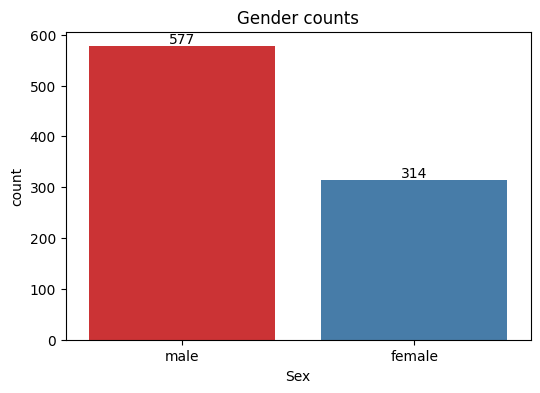

In [15]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = df['Sex'],data = df,palette = 'Set1')
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2,height),
        va = 'bottom',
        ha = 'center'
    )
plt.title('Gender counts')
plt.show()

In [16]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [17]:
# Replacing 'Age' columns with its mean value.
mean_age = df['Age'].mean()
df['Age'] = df["Age"].fillna(mean_age)
df['Age']

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

# Data Cleaning

In [18]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C


In [20]:
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'],axis = 1, inplace=True)

In [21]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [22]:
df.Embarked.value_counts()


Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

# Visualization

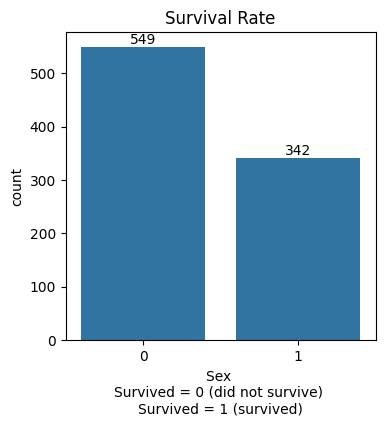

In [23]:
#ax = sns.barplot(x=df.Sex,y = df.Survived, data=df)
plt.figure(figsize=(4,4))
ax = sns.countplot(x = df.Survived)
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha = 'center',
        va = 'bottom'
    )
plt.xlabel('Sex \nSurvived = 0 (did not survive) \nSurvived = 1 (survived)')
plt.title("Survival Rate")
plt.show()
# 

# 

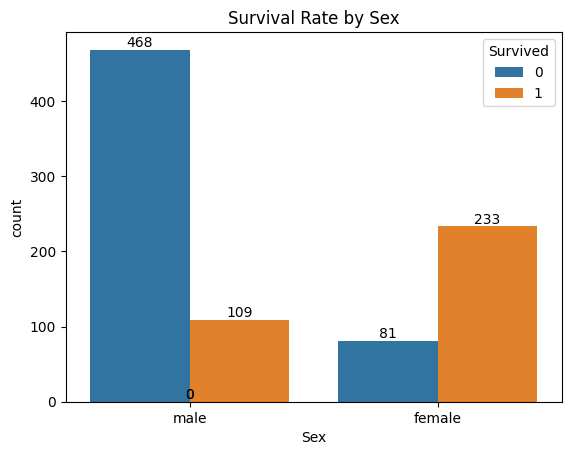

In [24]:
# Survived = 0 (did not survive)

# Survived = 1 (survived)

ax = sns.countplot(x = 'Sex',hue = 'Survived', data = df)
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha = 'center',
        va = 'bottom'
    )
plt.title("Survival Rate by Sex")
plt.show()

Sex
female    233
male      109
Name: Survived, dtype: int64


C:\Users\Qbits\AppData\Local\Temp\ipykernel_2180\1483212312.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = sex_survived.index, y = sex_survived, palette = "Set2")


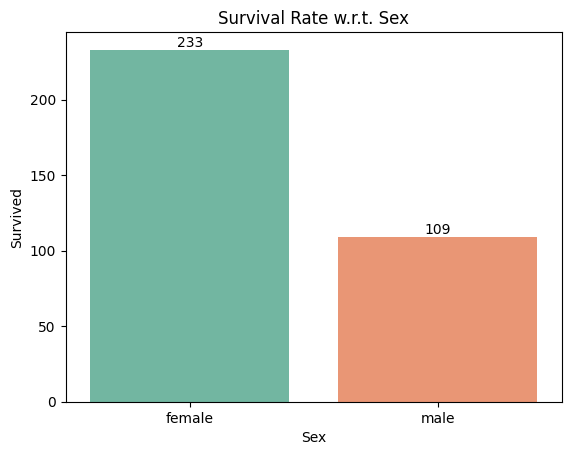

In [25]:
sex_survived = df.groupby('Sex')['Survived'].sum()
print(sex_survived)
ax = sns.barplot(x = sex_survived.index, y = sex_survived, palette = "Set2")
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha = 'center',
        va= 'bottom'
    )
plt.title('Survival Rate w.r.t. Sex')
plt.show()

0 -> Didn't Survive
1-> Survived


C:\Users\Qbits\AppData\Local\Temp\ipykernel_2180\719261787.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = df.Survived, palette = "Set2")


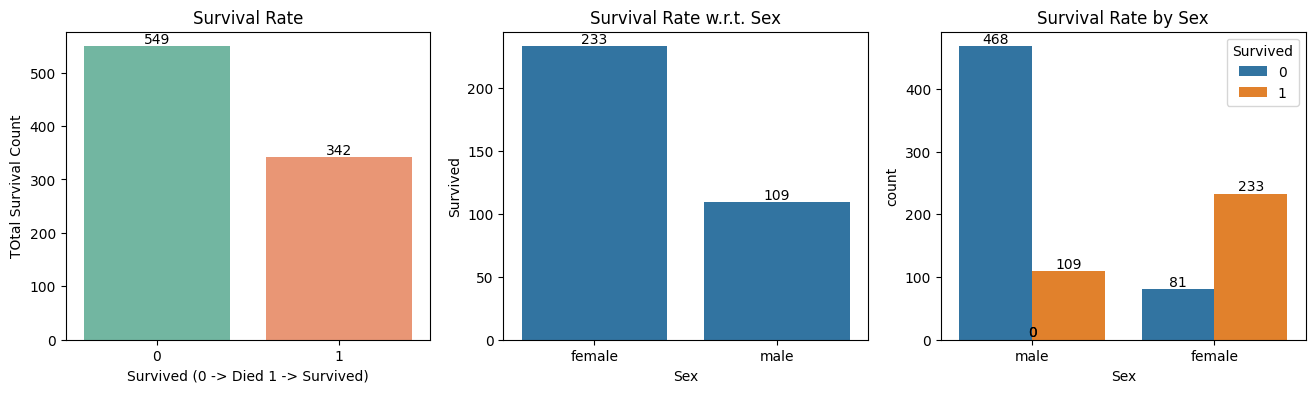

In [26]:
print("0 -> Didn't Survive\n1-> Survived")
plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
ax = sns.countplot(x = df.Survived, palette = "Set2")
#ax = sns.countplot(x='Survived', hue='Sex',data=df,palette='Set2')
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha = 'center',
        va = 'bottom'
    )
plt.xlabel('Survived (0 -> Died 1 -> Survived)')
plt.ylabel('TOtal Survival Count')
plt.title("Survival Rate")

plt.subplot(1,3,2)
sex_survived = df.groupby('Sex')['Survived'].sum()
#print(sex_survived)
colors = ['Red', 'Green']
ax = sns.barplot(x = sex_survived.index, y = sex_survived)
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha = 'center',
        va= 'bottom'
    )
plt.title('Survival Rate w.r.t. Sex')

plt.subplot(1,3,3)
ax = sns.countplot(x = 'Sex',hue = 'Survived', data = df)
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha = 'center',
        va = 'bottom'
    )

plt.title("Survival Rate by Sex")
plt.show()

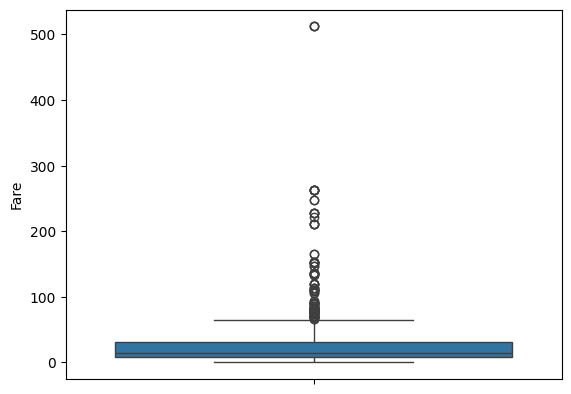

In [27]:
sns.boxplot(y = df.Fare)
plt.show()

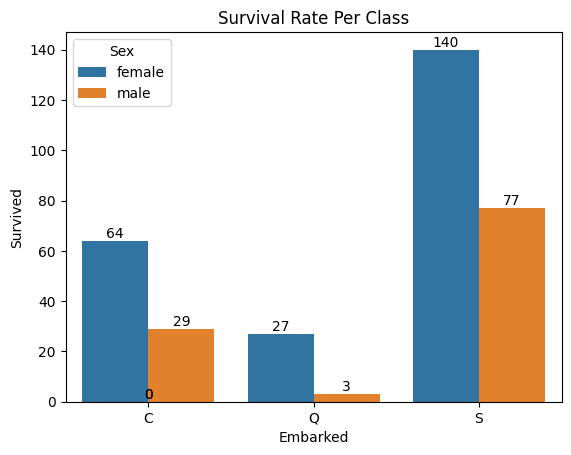

In [28]:
embarked_sex_survived = (
    df.groupby(['Embarked','Sex'])['Survived'].sum().reset_index()
)

ax = sns.barplot(x='Embarked',
                 y='Survived',
                 hue='Sex',
                 data=embarked_sex_survived)

for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                (bar.get_x() + bar.get_width()/2, height),
                ha='center',
                va='bottom')
plt.title('Survival Rate Per Class')
plt.show()

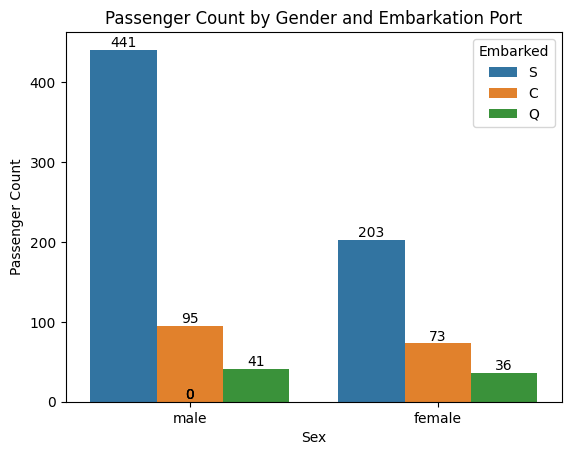

In [29]:
ax = sns.countplot(x='Sex',
                   hue='Embarked',
                   data=df)

for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha='center',
        va='bottom'
    )

plt.title("Passenger Count by Gender and Embarkation Port")
plt.xlabel("Sex")
plt.ylabel("Passenger Count")
plt.show()

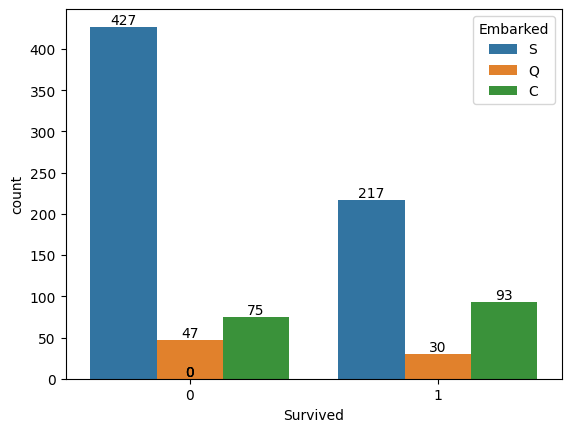

In [30]:
ax = sns.countplot(x = df.Survived, hue = df.Embarked)
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha = 'center',
        va = 'bottom'
    )
plt.show()

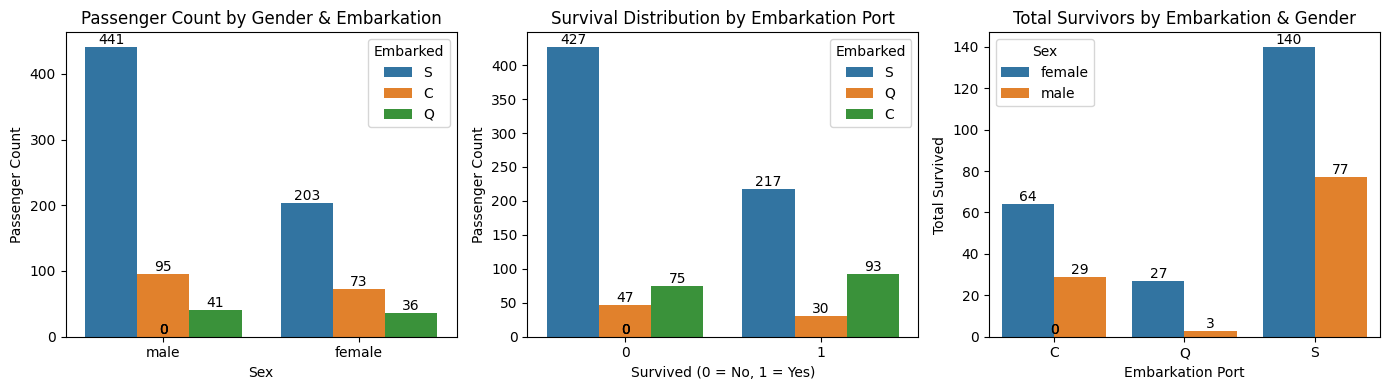

In [31]:
plt.figure(figsize=(14,4))

# ------------------ Subplot 1 ------------------
plt.subplot(1,3,1)
ax = sns.countplot(x='Sex',
                   hue='Embarked',
                   data=df)

for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                (bar.get_x() + bar.get_width()/2, height),
                ha='center',
                va='bottom')

plt.title("Passenger Count by Gender & Embarkation")
plt.xlabel("Sex")
plt.ylabel("Passenger Count")


# ------------------ Subplot 2 ------------------
plt.subplot(1,3,2)
ax = sns.countplot(x='Survived',
                   hue='Embarked',
                   data=df)

for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                (bar.get_x() + bar.get_width()/2, height),
                ha='center',
                va='bottom')

plt.title("Survival Distribution by Embarkation Port")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Passenger Count")


# ------------------ Subplot 3 ------------------
plt.subplot(1,3,3)

embarked_sex_survived = (
    df.groupby(['Embarked','Sex'])['Survived']
      .sum()
      .reset_index()
)

ax = sns.barplot(x='Embarked',
                 y='Survived',
                 hue='Sex',
                 data=embarked_sex_survived)

for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                (bar.get_x() + bar.get_width()/2, height),
                ha='center',
                va='bottom')

plt.title("Total Survivors by Embarkation & Gender")
plt.xlabel("Embarkation Port")
plt.ylabel("Total Survived")

plt.tight_layout()
plt.show()

# Encoding

In [32]:
# 'Sex' Columns Encoding
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

In [33]:
df.head(5)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,S
1,1,1,0,38.0,1,0,71.2833,C
2,1,3,0,26.0,0,0,7.9250,S
3,1,1,0,35.0,1,0,53.1000,S
4,0,3,1,35.0,0,0,8.0500,S


In [34]:
# 'Embarked' column Encoding
embarked_encoded = pd.get_dummies(df['Embarked'], drop_first=True, prefix = 'Embarked').astype(int)

df = pd.concat([df, embarked_encoded], axis=1)

# Then drop original column
df.drop('Embarked', axis=1, inplace=True)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int32  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked_Q  891 non-null    int32  
 8   Embarked_S  891 non-null    int32  
dtypes: float64(2), int32(3), int64(4)
memory usage: 52.3 KB


In [36]:
# Compute correlation matrix
corr_matrix = df.corr()

# Get correlation with Survived column
corr = corr_matrix['Survived']

print(corr)

Survived      1.000000
Pclass       -0.338481
Sex          -0.543351
Age          -0.069809
SibSp        -0.035322
Parch         0.081629
Fare          0.257307
Embarked_Q    0.003650
Embarked_S   -0.155660
Name: Survived, dtype: float64


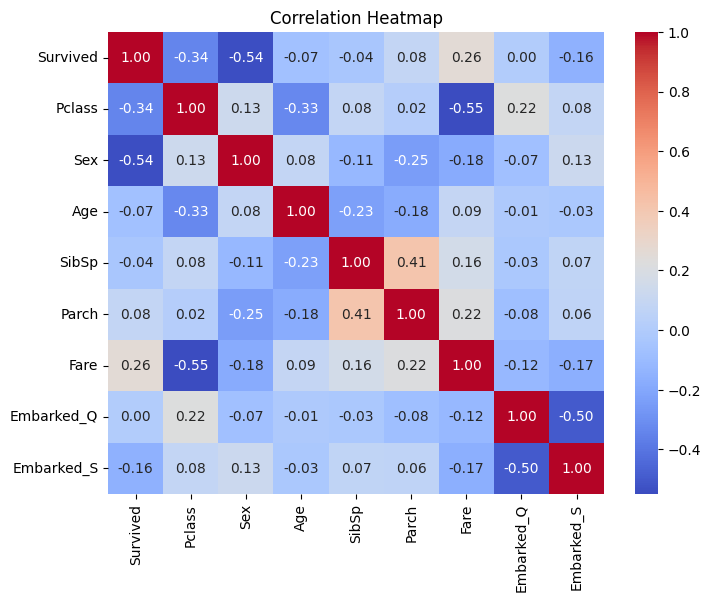

In [37]:
# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

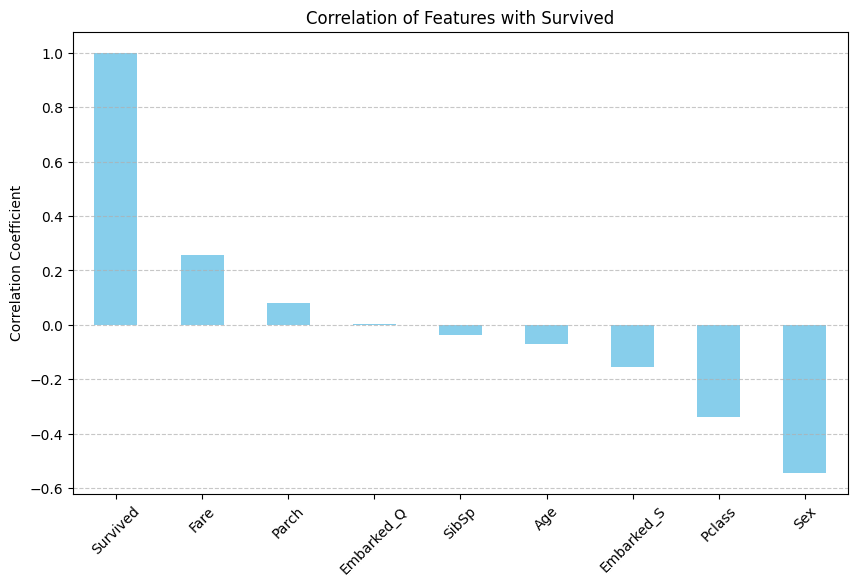

In [38]:
# Compute correlation matrix
corr_matrix = df.corr()

# Select only correlation with 'Survived'
corr_survived = corr_matrix['Survived'].sort_values(ascending=False)

# Plot bar chart
plt.figure(figsize=(10,6))
corr_survived.plot(kind='bar', color='skyblue')
plt.title("Correlation of Features with Survived")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [43]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.000000,1,0,7.2500,0,1
1,1,1,0,38.000000,1,0,71.2833,0,0
2,1,3,0,26.000000,0,0,7.9250,0,1
3,1,1,0,35.000000,1,0,53.1000,0,1
4,0,3,1,35.000000,0,0,8.0500,0,1
...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000,0,1
887,1,1,0,19.000000,0,0,30.0000,0,1
888,0,3,0,29.699118,1,2,23.4500,0,1
889,1,1,1,26.000000,0,0,30.0000,0,0


# Dataset Split

In [48]:
x = df.iloc[:, 1:9]
y = df['Survived']

In [49]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,3,1,22.0,1,0,7.2500,0,1
1,1,0,38.0,1,0,71.2833,0,0
2,3,0,26.0,0,0,7.9250,0,1
3,1,0,35.0,1,0,53.1000,0,1
4,3,1,35.0,0,0,8.0500,0,1


In [50]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

# Train_Test_Split

In [52]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [53]:
print('xtrain shape: ',xtrain.shape)
print('ytrain shape: ',ytrain.shape)
print('xtest.shape: ',xtest.shape)
print('ytest.shape: ',ytest.shape)

xtrain shape:  (712, 8)
ytrain shape:  (712,)
xtest.shape:  (179, 8)
ytest.shape:  (179,)


In [54]:
xtrain.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
331,1,1,45.5,0,0,28.5000,0,1
733,2,1,23.0,0,0,13.0000,0,1
382,3,1,32.0,0,0,7.9250,0,1
704,3,1,26.0,1,0,7.8542,0,1
813,3,0,6.0,4,2,31.2750,0,1


In [55]:
ytrain.head()

331    0
733    0
382    0
704    0
813    0
Name: Survived, dtype: int64

# Model Building

## KNeighborsClassifier

In [60]:
knn_cf = KNeighborsClassifier(n_neighbors = 5) # initial 
knn_cf = knn_cf.fit(xtrain,ytrain)

In [63]:
print('Train Score: ',knn_cf.score(xtrain,ytrain))
print('Test Score: ',knn_cf.score(xtest,ytest))

Train Score:  0.7935393258426966
Test Score:  0.7039106145251397


In [64]:
ypred = knn_cf.predict(xtest)
ypred

array([0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1], dtype=int64)

# Model Evaluation

In [65]:
print('Accuracy score: ',accuracy_score(ytest,ypred))

Accuracy score:  0.7039106145251397


In [67]:
print('Confusion matrix: \n', confusion_matrix(ytest,ypred))

Confusion matrix: 
 [[86 19]
 [34 40]]


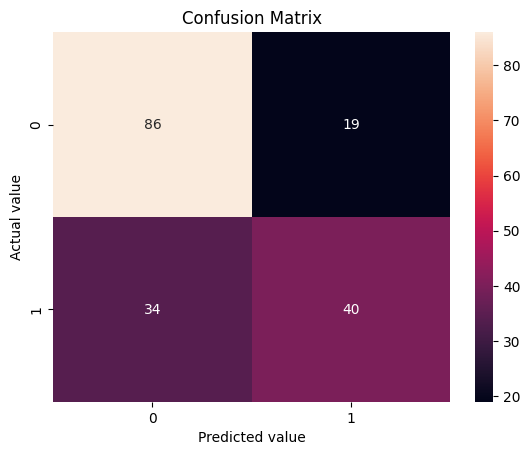

In [69]:
cm = confusion_matrix(ytest,ypred)

sns.heatmap(cm, annot = True)
plt.xlabel('Predicted value')
plt.ylabel('Actual value')
plt.title('Confusion Matrix')
plt.show()

In [77]:
print('Classification Report: \n',classification_report(ytest,ypred))

Classification Report: 
               precision    recall  f1-score   support

           0       0.72      0.82      0.76       105
           1       0.68      0.54      0.60        74

    accuracy                           0.70       179
   macro avg       0.70      0.68      0.68       179
weighted avg       0.70      0.70      0.70       179



In [80]:
xtest.shape

(179, 8)

# Hyperparameter Tuning

In [81]:
x.columns

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')

In [85]:
accuracy_score_train_list = []
accuracy_score_test_list = []

for i in range(1,31):
    print('K: ',i)
    knn_cf = KNeighborsClassifier(n_neighbors = i)
    knn_cf = knn_cf.fit(xtrain,ytrain)

    # Train case
    ypred_train = knn_cf.predict(xtrain)
    accuracy_score_train = accuracy_score(ytrain,ypred_train)
    accuracy_score_train_list.append(accuracy_score_train)

    #Test case
    accuracy_score_test = accuracy_score(ytest, ypred)
    accuracy_score_test_list.append(accuracy_score_test)

    print('Accuracy Score Train: ',accuracy_score_train)
    print('Accuracy Score Test: ',accuracy_score_test)
    

K:  1
Accuracy Score Train:  0.9691011235955056
Accuracy Score Test:  0.7039106145251397
K:  2
Accuracy Score Train:  0.8328651685393258
Accuracy Score Test:  0.7039106145251397
K:  3
Accuracy Score Train:  0.827247191011236
Accuracy Score Test:  0.7039106145251397
K:  4
Accuracy Score Train:  0.8019662921348315
Accuracy Score Test:  0.7039106145251397
K:  5
Accuracy Score Train:  0.7935393258426966
Accuracy Score Test:  0.7039106145251397
K:  6
Accuracy Score Train:  0.7556179775280899
Accuracy Score Test:  0.7039106145251397
K:  7
Accuracy Score Train:  0.7640449438202247
Accuracy Score Test:  0.7039106145251397
K:  8
Accuracy Score Train:  0.75
Accuracy Score Test:  0.7039106145251397
K:  9
Accuracy Score Train:  0.7570224719101124
Accuracy Score Test:  0.7039106145251397
K:  10
Accuracy Score Train:  0.7528089887640449
Accuracy Score Test:  0.7039106145251397
K:  11
Accuracy Score Train:  0.7556179775280899
Accuracy Score Test:  0.7039106145251397
K:  12
Accuracy Score Train:  0.74

In [86]:
# Find best K
import numpy as np
best_k = np.argmax(accuracy_score_test_list) + 1
print("Best K:", best_k)

Best K: 1


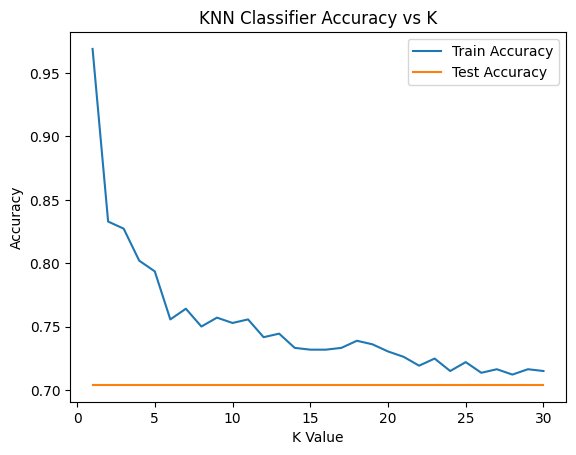

In [89]:
plt.plot(range(1,31), accuracy_score_train_list, label="Train Accuracy")
plt.plot(range(1,31), accuracy_score_test_list, label="Test Accuracy")

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Classifier Accuracy vs K")
plt.legend()
plt.show()

In [88]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [106]:
final_knn_cf = KNeighborsClassifier(n_neighbors = 1)
final_knn_cf.fit(xtrain, ytrain)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [107]:
print('Train score : ',final_knn_cf.score(xtrain,ytrain))
print('Test score: ',final_knn_cf.score(xtest,ytest))

Train score :  0.9691011235955056
Test score:  0.6815642458100558


In [108]:
y_pred_knn_final = final_knn_cf.predict(xtest)
y_pred_knn_final

array([0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1], dtype=int64)

In [109]:
print('Accuracy Score: ',accuracy_score(ytest,y_pred_knn_final))
print('\nClassification Report: \n', classification_report(ytest, y_pred_knn_final))
print('F1 Score : ',f1_score(ytest, y_pred_knn_final))

Accuracy Score:  0.6815642458100558

Classification Report: 
               precision    recall  f1-score   support

           0       0.70      0.80      0.75       105
           1       0.64      0.51      0.57        74

    accuracy                           0.68       179
   macro avg       0.67      0.66      0.66       179
weighted avg       0.68      0.68      0.67       179

F1 Score :  0.5714285714285714


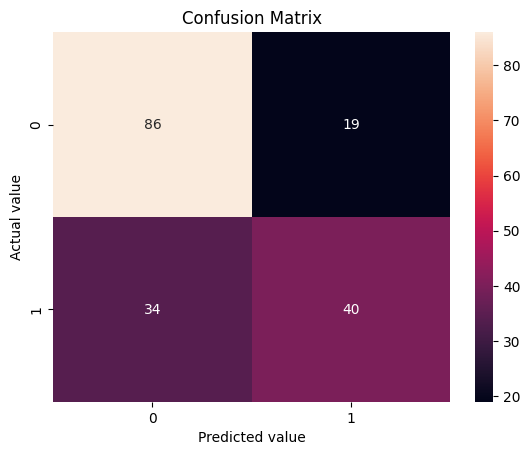

In [113]:
cm = confusion_matrix(ytest,ypred)

sns.heatmap(cm, annot = True)
plt.xlabel('Predicted value')
plt.ylabel('Actual value')
plt.title('Confusion Matrix')
plt.show()

In [105]:
print('Classification Report: \n',classification_report(ytest,ypred))

Classification Report: 
               precision    recall  f1-score   support

           0       0.72      0.82      0.76       105
           1       0.68      0.54      0.60        74

    accuracy                           0.70       179
   macro avg       0.70      0.68      0.68       179
weighted avg       0.70      0.70      0.70       179



## LogisticRegression

In [101]:
log_reg = LogisticRegression(max_iter = 1000)
log_reg.fit(xtrain,ytrain)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [102]:
print('Train score: ',log_reg.score(xtrain,ytrain))
print('Test score: ', log_reg.score(xtest,ytest))

Train score:  0.8019662921348315
Test score:  0.8100558659217877


In [116]:
print('Accuracy score: ',accuracy_score(ytest, log_reg.predict(xtest)))
print('Classification Report: \n',classification_report(ytest, log_reg.predict(xtest)))

Accuracy score:  0.8100558659217877
Classification Report: 
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



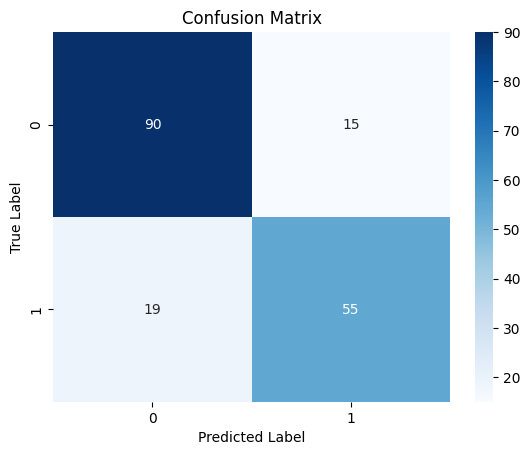

In [119]:
cm = confusion_matrix(ytest, log_reg.predict(xtest))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()